# 13. ROC, AUC, progi decyzyjne i macierz pomyłek

Ten notebook pokazuje ROC/AUC  (Receiver Operating Characteristic curve) na małych liczbach. Chodzi o intuicję:

> Model klasyfikacyjny często zwraca **score** albo prawdopodobieństwo. Dopiero próg zamienia score na klasę.

Dla danego progu liczymy macierz pomyłek:

$$
\begin{array}{c|cc}
 & y=1 & y=0 \\
\hline
\hat y=1 & TP & FP \\
\hat y=0 & FN & TN
\end{array}
$$

Najważniejsze miary ROC:

$$
TPR = sensitivity = recall = \frac{TP}{TP+FN}
$$

$$
FPR = 1-specificity = \frac{FP}{FP+TN}
$$

ROC rysuje $TPR$ względem $FPR$ dla wielu progów.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.precision', 6)

## 1. Małe dane: etykiety i score

`score` może być prawdopodobieństwem z regresji logistycznej albo dowolną wartością rankingową. ROC/AUC interesuje głównie kolejność: czy pozytywne przypadki mają wyższe score niż negatywne?

In [13]:
roc_df = pd.DataFrame({
    'sample': list('ABCDEFGHIJKL'),
    'y_true': [1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1],
    'score':  [0.95, 0.90, 0.82, 0.75, 0.70, 0.62, 0.60, 0.55, 0.45, 0.40, 0.30, 0.20],
})
roc_df.sort_values('score', ascending=False)

,sample,y_true,score
0,A,1,0.95
1,B,0,0.90
2,C,1,0.82
3,D,1,0.75
4,E,0,0.70
5,F,0,0.62
6,G,1,0.60
7,H,0,0.55
8,I,1,0.45
9,J,0,0.40


## 2. Macierz pomyłek dla jednego progu

Dla progu $t$:

$$
\hat y = I(score \ge t)
$$

Zmiana progu zmienia liczbę false positives i false negatives. Nie istnieje jeden idealny próg dla wszystkich problemów — zależy od kosztów błędów.

In [14]:
def confusion_at_threshold(y_true, scores, threshold):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    pred = (scores >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    P = tp + fn
    N = fp + tn
    precision = tp / (tp + fp) if (tp + fp) else np.nan
    recall = tp / P if P else np.nan
    specificity = tn / N if N else np.nan
    fpr = fp / N if N else np.nan
    f1 = 2*precision*recall/(precision+recall) if precision + recall > 0 else np.nan
    return {
        'threshold': threshold,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn,
        'TPR_recall_sensitivity': recall,
        'FPR': fpr,
        'specificity': specificity,
        'precision': precision,
        'F1': f1,
    }

pd.Series(confusion_at_threshold(roc_df['y_true'], roc_df['score'], threshold=0.5))

threshold                 0.500000
TP                        4.000000
FP                        4.000000
TN                        2.000000
FN                        2.000000
TPR_recall_sensitivity    0.666667
FPR                       0.666667
specificity               0.333333
precision                 0.500000
F1                        0.571429
dtype: float64

## 3. Sweep progów i punkty ROC

ROC budujemy przez **przesuwanie progu decyzyjnego**.

Reguła klasyfikacji:

$$
score \ge threshold \Rightarrow \hat y=1
$$

$$
score < threshold \Rightarrow \hat y=0
$$

Gdy obniżamy próg, coraz więcej obserwacji dostaje predykcję `1`.

- jeśli dodana obserwacja jest prawdziwie pozytywna, rośnie $TPR$,
- jeśli dodana obserwacja jest prawdziwie negatywna, rośnie $FPR$.

Dlatego ROC można czytać jak ścieżkę: **pozytyw idzie w górę, negatyw idzie w prawo**.

In [15]:
y_true = roc_df['y_true'].to_numpy()
scores = roc_df['score'].to_numpy()
thresholds = np.r_[np.inf, np.sort(np.unique(scores))[::-1], -np.inf]
roc_points = pd.DataFrame([confusion_at_threshold(y_true, scores, t) for t in thresholds])
roc_points[['threshold', 'TP', 'FP', 'TN', 'FN', 'TPR_recall_sensitivity', 'FPR', 'precision', 'F1']]

,threshold,TP,FP,TN,FN,TPR_recall_sensitivity,FPR,precision,F1
0,inf,0,0,6,6,0.000000,0.000000,NaN,NaN
1,0.95,1,0,6,5,0.166667,0.000000,1.000000,0.285714
2,0.90,1,1,5,5,0.166667,0.166667,0.500000,0.250000
3,0.82,2,1,5,4,0.333333,0.166667,0.666667,0.444444
4,0.75,3,1,5,3,0.500000,0.166667,0.750000,0.600000
5,0.70,3,2,4,3,0.500000,0.333333,0.600000,0.545455
6,0.62,3,3,3,3,0.500000,0.500000,0.500000,0.500000
7,0.60,4,3,3,2,0.666667,0.500000,0.571429,0.615385
8,0.55,4,4,2,2,0.666667,0.666667,0.500000,0.571429
9,0.45,5,4,2,1,0.833333,0.666667,0.555556,0.666667


### 3.1. Tablicowe budowanie ROC

Posortujmy obserwacje od największego score do najmniejszego.

Kiedy threshold spada do score kolejnej obserwacji, ta obserwacja zaczyna być klasyfikowana jako pozytywna.

In [16]:
# Liczba prawdziwych pozytywów i negatywów.
# Te liczby są mianownikami we wzorach na TPR i FPR.
P = int((roc_df['y_true'] == 1).sum())
N = int((roc_df['y_true'] == 0).sum())

roc_path = roc_df.sort_values('score', ascending=False).copy()

# Jeśli y_true=1, ROC robi krok w górę: TPR + 1/P.
# Jeśli y_true=0, ROC robi krok w prawo: FPR + 1/N.
roc_path['ROC_step'] = np.where(
    roc_path['y_true'] == 1,
    f'krok w górę: TPR + 1/{P}',
    f'krok w prawo: FPR + 1/{N}'
)

roc_path[['sample', 'y_true', 'score', 'ROC_step']]

,sample,y_true,score,ROC_step
0,A,1,0.95,krok w górę: TPR + 1/6
1,B,0,0.90,krok w prawo: FPR + 1/6
2,C,1,0.82,krok w górę: TPR + 1/6
3,D,1,0.75,krok w górę: TPR + 1/6
4,E,0,0.70,krok w prawo: FPR + 1/6
5,F,0,0.62,krok w prawo: FPR + 1/6
6,G,1,0.60,krok w górę: TPR + 1/6
7,H,0,0.55,krok w prawo: FPR + 1/6
8,I,1,0.45,krok w górę: TPR + 1/6
9,J,0,0.40,krok w prawo: FPR + 1/6


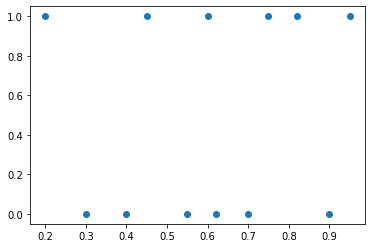

In [17]:
plt.scatter(scores,y_true)

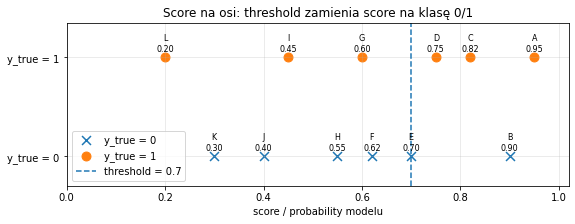

In [18]:
# Wizualizacja score'ów na jednej osi.
# Punkty na górze to y_true=1, punkty na dole to y_true=0.
# Pionowa linia pokazuje wybrany threshold.
#
# Reguła:
# score >= threshold -> model przewiduje klasę 1
# score < threshold  -> model przewiduje klasę 0

threshold_to_show = 0.70

score_plot = roc_df.sort_values("score").copy()
score_plot["y_axis"] = score_plot["y_true"]

fig, ax = plt.subplots(figsize=(9, 3))

# Punkty negatywne
neg = score_plot[score_plot["y_true"] == 0]
ax.scatter(
    neg["score"],
    neg["y_axis"],
    marker="x",
    s=80,
    label="y_true = 0"
)

# Punkty pozytywne
pos = score_plot[score_plot["y_true"] == 1]
ax.scatter(
    pos["score"],
    pos["y_axis"],
    marker="o",
    s=80,
    label="y_true = 1"
)

# Podpisy punktów: sample + score
for row in score_plot.itertuples():
    ax.text(
        row.score,
        row.y_axis + 0.06,
        f"{row.sample}\n{row.score:.2f}",
        ha="center",
        fontsize=8
    )

# Threshold jako pionowa linia
ax.axvline(
    threshold_to_show,
    linestyle="--",
    label=f"threshold = {threshold_to_show}"
)

ax.set_xlim(0, 1.02)
ax.set_ylim(-0.3, 1.35)
ax.set_yticks([0, 1])
ax.set_yticklabels(["y_true = 0", "y_true = 1"])
ax.set_xlabel("score / probability modelu")
ax.set_title("Score na osi: threshold zamienia score na klasę 0/1")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

Na tym wykresie każdy punkt ma swój `score`.

Pionowa linia to `threshold`.

- punkty po prawej stronie thresholda model klasyfikuje jako `1`,
- punkty po lewej stronie thresholda model klasyfikuje jako `0`.

ROC powstaje wtedy, gdy przesuwamy threshold od bardzo wysokiego do bardzo niskiego i za każdym razem liczymy `TPR` oraz `FPR`.

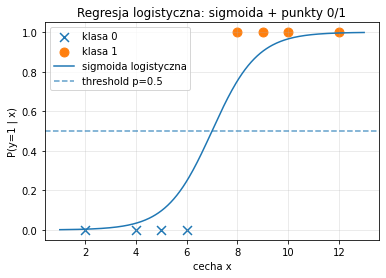

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Przykładowe dane 1D
X = np.array([[2], [4], [5], [6], [8], [9], [10], [12]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])

# Model logistyczny
clf = LogisticRegression()
clf.fit(X, y)

# Siatka x do rysowania krzywej
x_grid = np.linspace(X.min() - 1, X.max() + 1, 300).reshape(-1, 1)
p_grid = clf.predict_proba(x_grid)[:, 1]

# Wykres
plt.figure(figsize=(6, 4))

# Punkty danych
plt.scatter(X[y == 0], y[y == 0], marker='x', s=80, label='klasa 0')
plt.scatter(X[y == 1], y[y == 1], marker='o', s=80, label='klasa 1')

# Krzywa logistyczna
plt.plot(x_grid, p_grid, label='sigmoida logistyczna')

# Threshold 0.5
plt.axhline(0.5, linestyle='--', alpha=0.7, label='threshold p=0.5')

plt.xlabel('cecha x')
plt.ylabel('P(y=1 | x)')
plt.title('Regresja logistyczna: sigmoida + punkty 0/1')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 3.2. Tabela progów ROC

Każdy threshold daje inną macierz pomyłek i inny punkt ROC:

$$
TPR=\frac{TP}{TP+FN}
$$

$$
FPR=\frac{FP}{FP+TN}
$$

In [20]:
roc_table = roc_points.copy()
roc_table['threshold_show'] = roc_table['threshold'].replace({np.inf: '+inf', -np.inf: '-inf'})

roc_table[[
    'threshold_show',
    'TP', 'FP', 'TN', 'FN',
    'TPR_recall_sensitivity', 'FPR'
]].rename(columns={
    'threshold_show': 'threshold',
    'TPR_recall_sensitivity': 'TPR'
})

,threshold,TP,FP,TN,FN,TPR,FPR
0,+inf,0,0,6,6,0.000000,0.000000
1,0.95,1,0,6,5,0.166667,0.000000
2,0.9,1,1,5,5,0.166667,0.166667
3,0.82,2,1,5,4,0.333333,0.166667
4,0.75,3,1,5,3,0.500000,0.166667
5,0.7,3,2,4,3,0.500000,0.333333
6,0.62,3,3,3,3,0.500000,0.500000
7,0.6,4,3,3,2,0.666667,0.500000
8,0.55,4,4,2,2,0.666667,0.666667
9,0.45,5,4,2,1,0.833333,0.666667


### 3.3. ROC z podpisanymi progami

Na wykresie:

- oś X to $FPR$, czyli fałszywe alarmy,
- oś Y to $TPR$, czyli wykryte pozytywy,
- przekątna to model losowy,
- im bliżej lewego górnego rogu, tym lepiej.

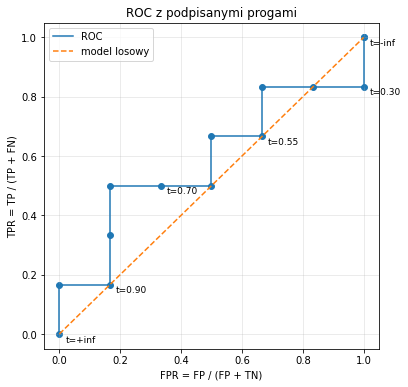

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.step(
    roc_points['FPR'],
    roc_points['TPR_recall_sensitivity'],
    where='post',
    label='ROC'
)

ax.scatter(
    roc_points['FPR'],
    roc_points['TPR_recall_sensitivity'],
    s=35
)

ax.plot([0, 1], [0, 1], linestyle='--', label='model losowy')

# Opisujemy tylko kilka progów, żeby wykres był czytelny.
thresholds_to_label = [np.inf, 0.90, 0.70, 0.55, 0.30, -np.inf]

for _, row in roc_points.iterrows():
    t = row['threshold']
    should_label = any(
        (np.isinf(t) and np.isinf(label) and np.sign(t) == np.sign(label)) or
        (not np.isinf(t) and not np.isinf(label) and abs(t - label) < 1e-9)
        for label in thresholds_to_label
    )

    if should_label:
        if np.isposinf(t):
            label = 't=+inf'
        elif np.isneginf(t):
            label = 't=-inf'
        else:
            label = f't={t:.2f}'

        ax.annotate(
            label,
            (row['FPR'], row['TPR_recall_sensitivity']),
            textcoords='offset points',
            xytext=(6, -8),
            fontsize=9
        )

ax.set_xlabel('FPR = FP / (FP + TN)')
ax.set_ylabel('TPR = TP / (TP + FN)')
ax.set_title('ROC z podpisanymi progami')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

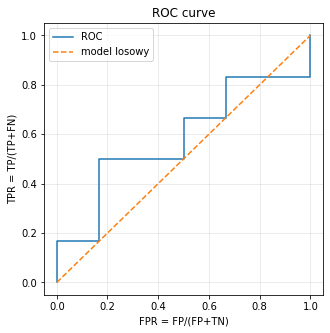

In [22]:
# Ten sam ROC, ale w czystej wersji bez podpisanych progów.
fig, ax = plt.subplots(figsize=(5, 5))
ax.step(roc_points['FPR'], roc_points['TPR_recall_sensitivity'], where='post', label='ROC')
ax.plot([0, 1], [0, 1], linestyle='--', label='model losowy')
ax.set_xlabel('FPR = FP/(FP+TN)')
ax.set_ylabel('TPR = TP/(TP+FN)')
ax.set_title('ROC curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 4. AUC ręcznie: metoda trapezów

AUC to pole pod krzywą ROC. Gdy mamy punkty $(FPR,TPR)$, możemy policzyć pole metodą trapezów:

$$
AUC \approx \sum_i \frac{TPR_i+TPR_{i+1}}{2}(FPR_{i+1}-FPR_i)
$$

Dla krzywej schodkowej z progami jest to dokładny sposób liczenia pola po uporządkowaniu punktów.

In [23]:
roc_sorted = roc_points.sort_values(['FPR', 'TPR_recall_sensitivity']).drop_duplicates(['FPR', 'TPR_recall_sensitivity'])
auc_trapezoid = np.trapz(roc_sorted['TPR_recall_sensitivity'], roc_sorted['FPR'])
auc_trapezoid

0.5833333333333334

## 5. AUC ręcznie: interpretacja par rankingowych

AUC można też rozumieć jako prawdopodobieństwo, że losowy przypadek pozytywny ma wyższy score niż losowy przypadek negatywny.

Liczymy wszystkie pary `(positive, negative)`:

- jeśli score pozytywnego jest większy, dostajemy $1$ punkt,
- jeśli score jest równy, dostajemy $0.5$ punktu,
- jeśli score pozytywnego jest mniejszy, dostajemy $0$ punktów.

$$
AUC = \frac{\#(score_+ > score_-) + 0.5\#(score_+ = score_-)}{n_+n_-}
$$

In [24]:
pos_scores = scores[y_true == 1]
neg_scores = scores[y_true == 0]
win = 0
Tie = 0
for ps in pos_scores:
    for ns in neg_scores:
        if ps > ns:
            win += 1
        elif ps == ns:
            Tie += 1
auc_pairwise = (win + 0.5*Tie) / (len(pos_scores)*len(neg_scores))

pd.Series({
    'positive_count': len(pos_scores),
    'negative_count': len(neg_scores),
    'pairs': len(pos_scores)*len(neg_scores),
    'wins_positive_score_higher': win,
    'ties': Tie,
    'AUC_pairwise': auc_pairwise,
    'AUC_trapezoid': auc_trapezoid,
})

positive_count                 6.000000
negative_count                 6.000000
pairs                         36.000000
wins_positive_score_higher    21.000000
ties                           0.000000
AUC_pairwise                   0.583333
AUC_trapezoid                  0.583333
dtype: float64

In [25]:
try:
    from sklearn.metrics import roc_auc_score, roc_curve
    sklearn_auc = roc_auc_score(y_true, scores)
except Exception as exc:
    sklearn_auc = f'sklearn unavailable: {exc}'

sklearn_auc

0.5833333333333335

## 6. Wybór progu: Youden, F1, koszty

ROC/AUC ocenia ranking, ale praktyczna decyzja wymaga progu.

Popularna prosta reguła:

$$
J = TPR - FPR
$$

czyli indeks Youdena. Wybieramy próg z największym $J$.

Ale w prawdziwych zastosowaniach próg powinien zależeć od kosztów:

- false negative może być bardzo kosztowny w medycynie,
- false positive może być kosztowny w systemie alarmowym,
- czasem liczy się precision, czasem recall.

In [26]:
threshold_metrics = roc_points.copy()
threshold_metrics['Youden_J'] = threshold_metrics['TPR_recall_sensitivity'] - threshold_metrics['FPR']
threshold_metrics.replace([np.inf, -np.inf], ['+inf', '-inf'])[['threshold','TPR_recall_sensitivity','FPR','precision','F1','Youden_J']]

,threshold,TPR_recall_sensitivity,FPR,precision,F1,Youden_J
0,+inf,0.000000,0.000000,NaN,NaN,0.000000
1,0.95,0.166667,0.000000,1.000000,0.285714,0.166667
2,0.9,0.166667,0.166667,0.500000,0.250000,0.000000
3,0.82,0.333333,0.166667,0.666667,0.444444,0.166667
4,0.75,0.500000,0.166667,0.750000,0.600000,0.333333
5,0.7,0.500000,0.333333,0.600000,0.545455,0.166667
6,0.62,0.500000,0.500000,0.500000,0.500000,0.000000
7,0.6,0.666667,0.500000,0.571429,0.615385,0.166667
8,0.55,0.666667,0.666667,0.500000,0.571429,0.000000
9,0.45,0.833333,0.666667,0.555556,0.666667,0.166667


In [27]:
best_youden = threshold_metrics.loc[threshold_metrics['Youden_J'].idxmax()]
best_f1 = threshold_metrics.loc[threshold_metrics['F1'].idxmax()]
pd.DataFrame([best_youden, best_f1], index=['best_Youden_J', 'best_F1'])[['threshold','TP','FP','TN','FN','TPR_recall_sensitivity','FPR','precision','F1','Youden_J']]

,threshold,TP,FP,TN,FN,TPR_recall_sensitivity,FPR,precision,F1,Youden_J
best_Youden_J,0.75,3.0,1.0,5.0,3.0,0.500000,0.166667,0.750000,0.600000,0.333333
best_F1,0.45,5.0,4.0,2.0,1.0,0.833333,0.666667,0.555556,0.666667,0.166667


## 7. Mini-ćwiczenia

### Ćwiczenie A

Dla progu $0.8$ policz z tabeli, ile jest $TP$, $FP$, $TN$, $FN$.

### Ćwiczenie B

Jeśli $TP=8$, $FN=2$, $FP=5$, $TN=15$, to:

$$
TPR=\frac{8}{8+2}=0.8
$$

$$
FPR=\frac{5}{5+15}=0.25
$$

### Ćwiczenie C

Jeśli AUC = $0.9$, to model zwykle bardzo dobrze ustawia przypadki pozytywne wyżej niż negatywne. To nie mówi jeszcze, jaki próg jest najlepszy.

### Ćwiczenie D

W tabeli `roc_path` znajdź pierwszy przypadek z `y_true=0`.
Co stanie się z wykresem ROC, gdy próg spadnie do jego score?

**Odpowiedź:** krzywa zrobi krok w prawo, bo rośnie $FPR$.
